# Phase 3: UMAP, Clustering & Thyrocyte Isolation
Map the tumour microenvironment on the Harmony-corrected embedding, annotate lineages by marker scores, and extract thyrocytes (epithelial tumour + normal cells) for progression analysis.

### Cell 1: Imports & Load Phase 2 Output

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ad.settings.allow_write_nullable_strings = True  # needed to save .h5ad with pandas 2.x
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=80, facecolor="white")

PROCESSED_DIR = os.path.join(os.getcwd(), "processed_data")
STAGES = ["Paratumor", "Primary Tumor", "LN Metastasis", "RAI-Refractory Metastasis"]

adata = sc.read_h5ad(os.path.join(PROCESSED_DIR, "adata_processed_qc.h5ad"))
print(adata)

AnnData object with n_obs × n_vars = 195352 × 26825
    obs: 'sample_id', 'gsm_id', 'patient_id', 'tissue_type', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca', 'X_pca_harmony'
    layers: None (.X)


### Cell 2: Neighbour Graph, UMAP & Leiden Clustering
The graph is built on `X_pca_harmony`, so cells group by biology rather than by patient.

computing neighbors


    finished (0:01:31)


computing UMAP


    finished (0:04:11)


running Leiden clustering


    finished (0:00:11)


Leiden clusters: 24


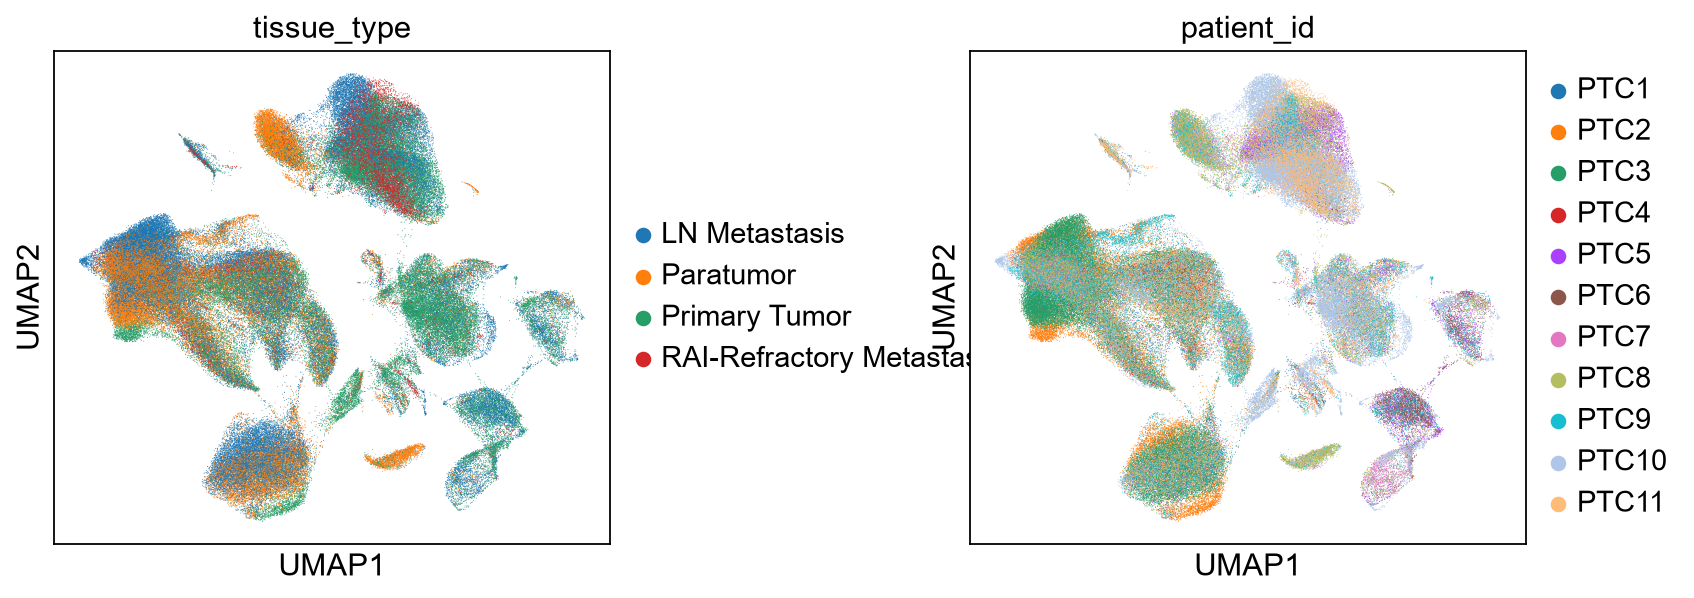

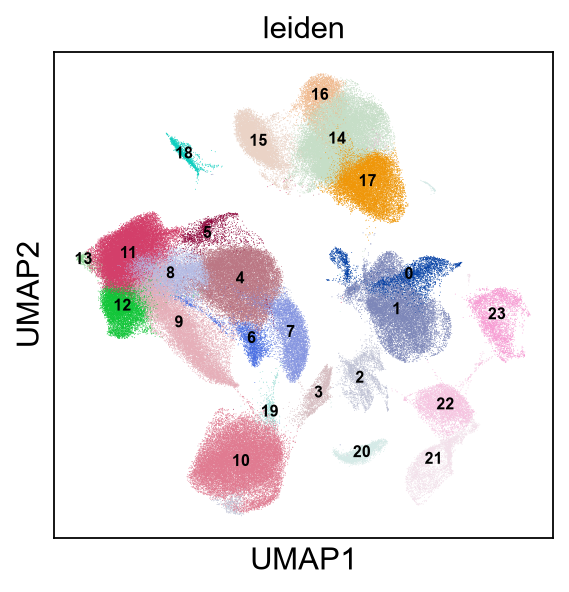

In [2]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, use_rep="X_pca_harmony")
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.8, key_added="leiden", flavor="igraph", n_iterations=2, directed=False)
print("Leiden clusters:", adata.obs["leiden"].nunique())

# Patients should be well mixed after Harmony; tissue stages may still separate biologically
sc.pl.umap(adata, color=["tissue_type", "patient_id"], wspace=0.5)
sc.pl.umap(adata, color="leiden", legend_loc="on data", legend_fontsize=7)

### Cell 3: Marker-Based Annotation
Each Leiden cluster is assigned the lineage with the highest mean marker score. A broad panel is used so immune/stromal clusters are not forced into the thyrocyte label.

computing score 'score_Thyrocytes'


    finished (0:00:02)


computing score 'score_T-cells'


    finished (0:00:01)


computing score 'score_NK cells'


...

computing score 'score_Fibroblasts'


    finished (0:00:01)


computing score 'score_Endothelial'


    finished (0:00:01)


leiden           0        1             2             3        4        5         6         7        8        9       10       11       12       13          14          15          16          17            18       19           20           21           22           23
cell_type  Myeloid  Myeloid  Plasma cells  Plasma cells  T-cells  T-cells  NK cells  NK cells  T-cells  T-cells  B cells  T-cells  T-cells  T-cells  Thyrocytes  Thyrocytes  Thyrocytes  Thyrocytes  Plasma cells  B cells  Endothelial  Fibroblasts  Fibroblasts  Endothelial


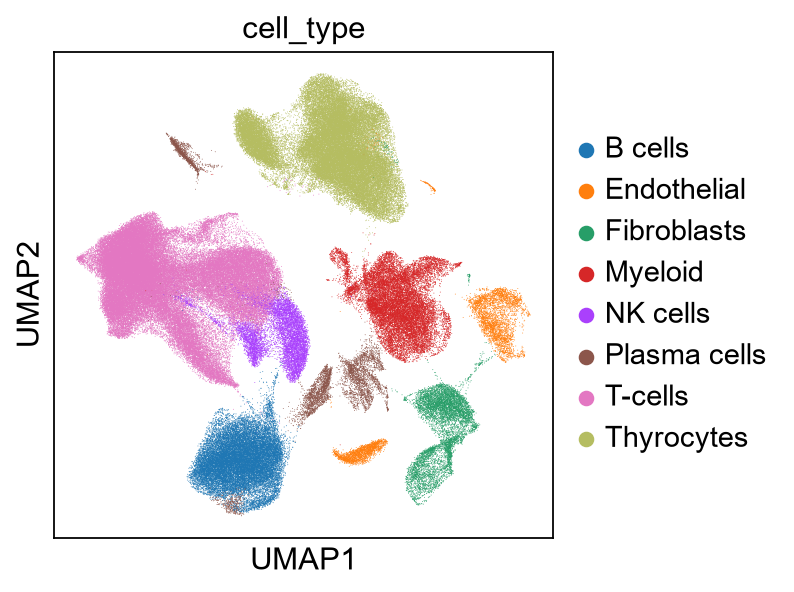

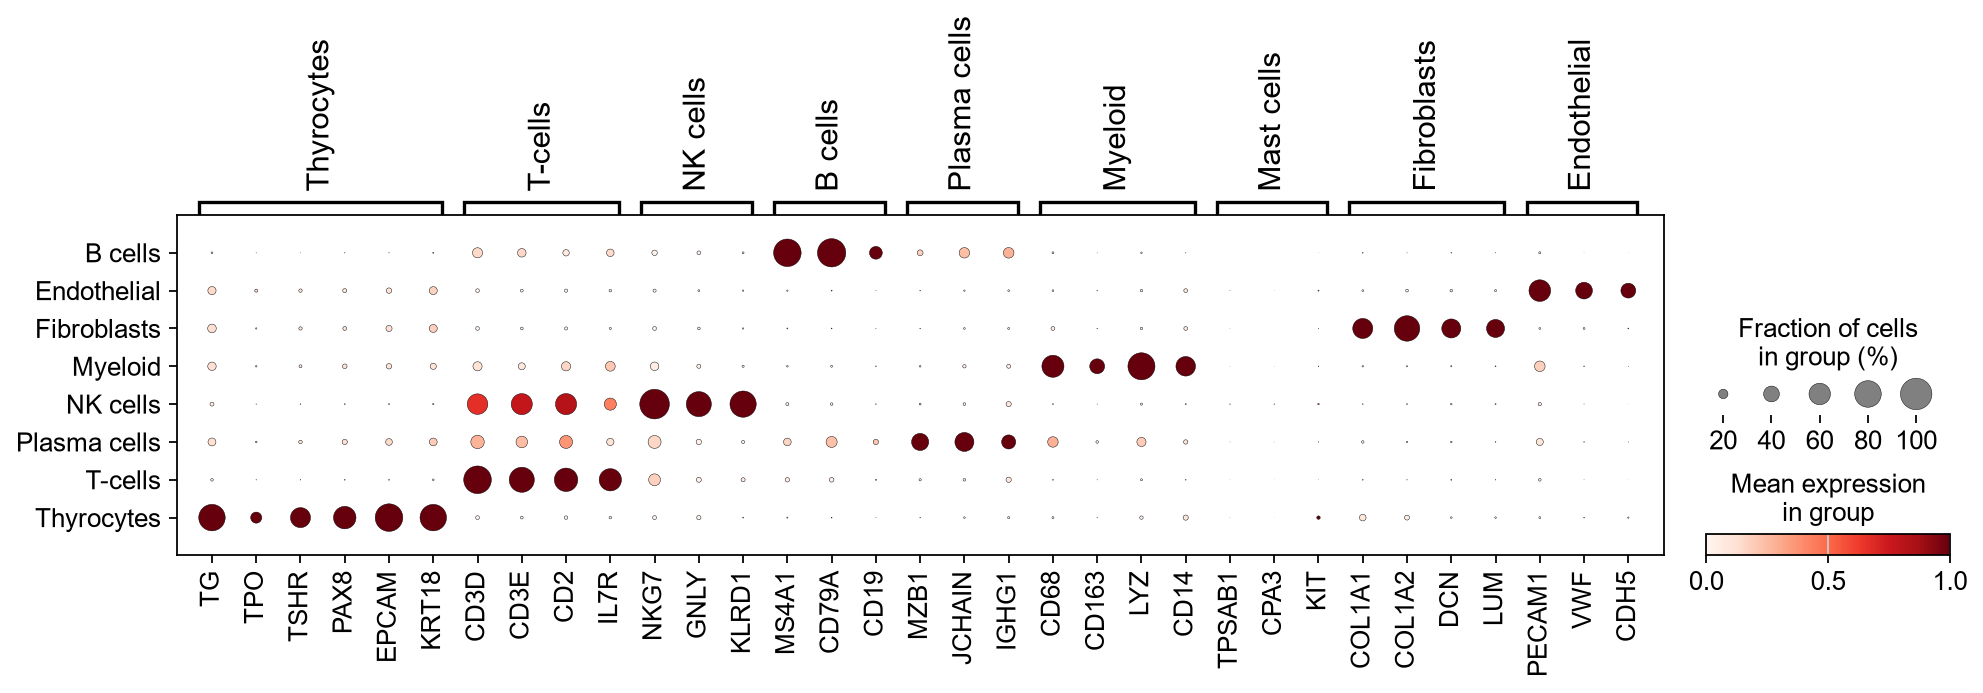

In [3]:
markers = {
    "Thyrocytes":   ["TG", "TPO", "TSHR", "PAX8", "EPCAM", "KRT18"],
    "T-cells":      ["CD3D", "CD3E", "CD2", "IL7R"],
    "NK cells":     ["NKG7", "GNLY", "KLRD1"],
    "B cells":      ["MS4A1", "CD79A", "CD19"],
    "Plasma cells": ["MZB1", "JCHAIN", "IGHG1"],
    "Myeloid":      ["CD68", "CD163", "LYZ", "CD14"],
    "Mast cells":   ["TPSAB1", "CPA3", "KIT"],
    "Fibroblasts":  ["COL1A1", "COL1A2", "DCN", "LUM"],
    "Endothelial":  ["PECAM1", "VWF", "CDH5"],
}
markers = {ct: [g for g in genes if g in adata.var_names] for ct, genes in markers.items()}

# use_raw=False: score on log-normalised X (adata.raw holds raw counts)
for ct, genes in markers.items():
    sc.tl.score_genes(adata, gene_list=genes, score_name=f"score_{ct}", use_raw=False)

score_cols = [f"score_{ct}" for ct in markers]
scores = adata.obs.groupby("leiden", observed=True)[score_cols].mean()
cluster_to_type = scores.idxmax(axis=1).str.replace("score_", "", regex=False)
adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_to_type).astype("category")

print(cluster_to_type.to_frame("cell_type").T.to_string())
sc.pl.umap(adata, color="cell_type")
sc.pl.dotplot(adata, markers, groupby="cell_type", use_raw=False, standard_scale="var")

### Cell 4: Cell-Type Composition per Stage

tissue_type   Paratumor  Primary Tumor  LN Metastasis  \
cell_type                                               
B cells            9916           2594          10452   
Endothelial        1978           2007           1759   
Fibroblasts         210           3759           3991   
Myeloid            1465          12798           3237   
NK cells           2161           4018           2126   
Plasma cells        921           3619           1457   
T-cells           27133          15922          29773   
Thyrocytes         6823          20533          16723   

tissue_type   RAI-Refractory Metastasis  
cell_type                                
B cells                              68  
Endothelial                          61  
Fibroblasts                         112  
Myeloid                             962  
NK cells                            465  
Plasma cells                        431  
T-cells                            2538  
Thyrocytes                         5340  


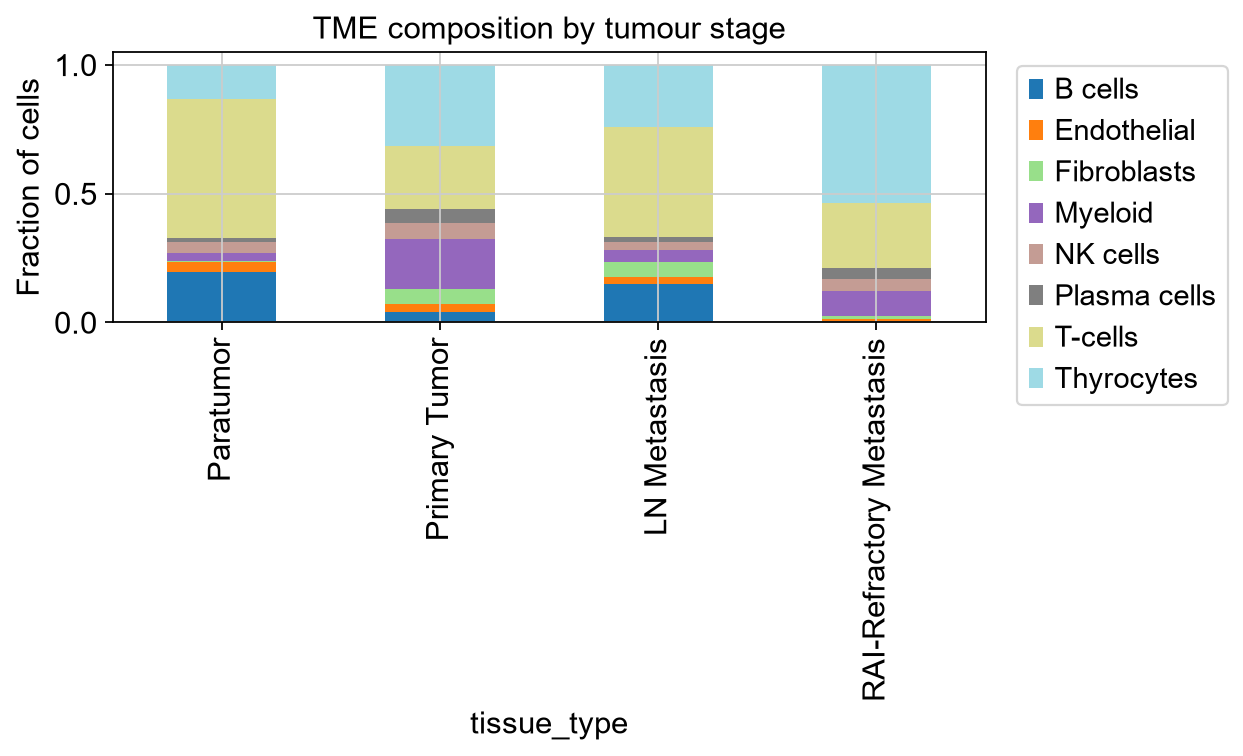

In [4]:
composition = pd.crosstab(adata.obs["cell_type"], adata.obs["tissue_type"])[STAGES]
print(composition)

(composition / composition.sum()).T.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="tab20")
plt.ylabel("Fraction of cells")
plt.title("TME composition by tumour stage")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Cell 5: Save Clustered Atlas & Thyrocyte Subset

In [5]:
adata.write_h5ad(os.path.join(PROCESSED_DIR, "adata_clustered.h5ad"), compression="gzip")

adata_thyrocytes = adata[adata.obs["cell_type"] == "Thyrocytes", :].copy()
print(adata_thyrocytes)
print(adata_thyrocytes.obs["tissue_type"].value_counts())
adata_thyrocytes.write_h5ad(os.path.join(PROCESSED_DIR, "adata_thyrocytes.h5ad"), compression="gzip")
print("Phase 3 Complete!")

AnnData object with n_obs × n_vars = 49419 × 26825
    obs: 'sample_id', 'gsm_id', 'patient_id', 'tissue_type', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'score_Thyrocytes', 'score_T-cells', 'score_NK cells', 'score_B cells', 'score_Plasma cells', 'score_Myeloid', 'score_Mast cells', 'score_Fibroblasts', 'score_Endothelial', 'cell_type'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'tissue_type_colors', 'patient_id_colors', 'leiden_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    obsp: 'distances', 'connectivities'
    layers: None (.X)
tissue_type
Primary Tumor                20533
LN Metastasis                16723
Paratumor                     6823
RAI-Refractory Metastasis     5340
Name: count, dtype: int64


Phase 3 Complete!
